<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
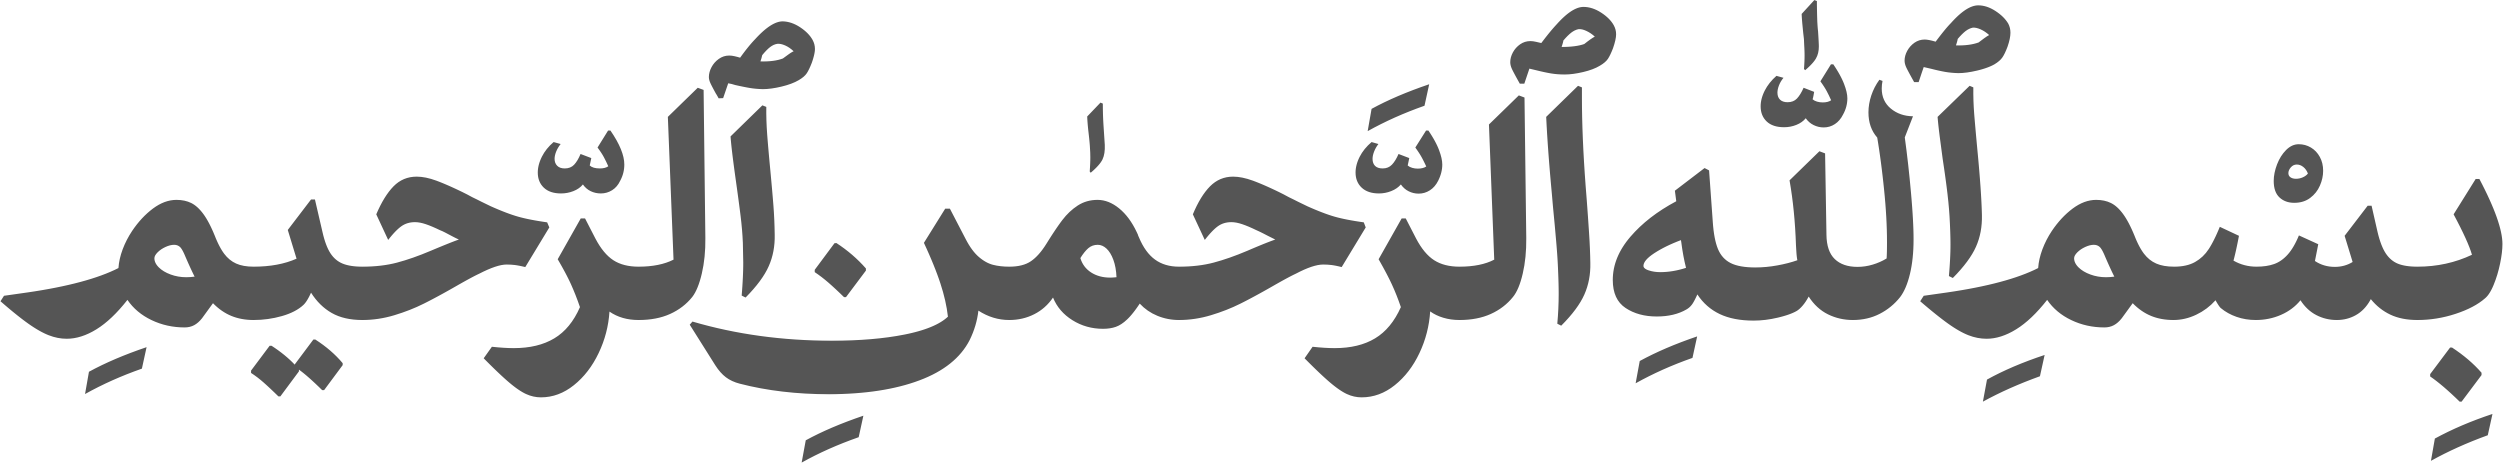
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
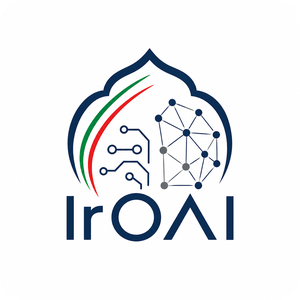
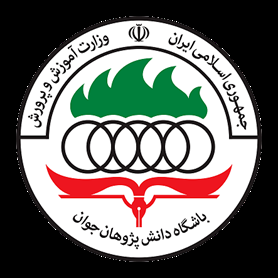
</div>
</div>
<h1 style="text-align: right;">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right;">پیاده‌سازی درخت تصمیم از صفر</h2>
<p style="text-align: right;"><b>موضوع:</b> درخت‌های تصمیم — طبقه‌بندی و رگرسیون</p>
<p style="text-align: right;">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه کار خودتان است.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">مقدمه</h2><p style="text-align: right;">سلام! در این تمرین قرار است <b>درخت تصمیم (Decision Tree)</b> را از صفر بسازیم و بعد آن را با نسخه آماده کتابخانه <code dir="ltr">scikit-learn</code> مقایسه کنیم. درخت تصمیم یک مدل <b>حریصانه و بازگشتی</b> است؛ یعنی مرحله به مرحله فضای ویژگی‌ها را با تقسیم‌های دودویی به ناحیه‌های کوچک‌تر می‌شکند تا در هر ناحیه پاسخ «تمیزتری» داشته باشیم.</p><p style="text-align: right;">یک نکته خیلی مهم که شاید در نگاه اول به چشم نیاید این است که <b>درخت طبقه‌بندی و درخت رگرسیون، در واقع یک الگوریتم واحد هستند</b>. تنها دو بخش از آن برای هر مسئله فرق می‌کند:</p><ul style="text-align: right;"><li style="text-align: right;"><b>تابع ناخالصی</b>: برای طبقه‌بندی از «جینی» یا «آنتروپی» استفاده می‌کنیم و برای رگرسیون از «میانگین مربعات خطا».</li><li style="text-align: right;"><b>مقدار برگ</b>: برای طبقه‌بندی، «طبقه اکثریت» و برای رگرسیون، «میانگین هدف‌ها» را برمی‌گردانیم.</li></ul><p style="text-align: right;">برای همین، یک کلاس واحد به نام <code dir="ltr">DecisionTree</code> می‌سازیم که با یک پارامتر کوچک به نام <code dir="ltr">problem_type</code> هم برای طبقه‌بندی و هم برای رگرسیون کار کند. این انتخابِ طراحی، همان چیزی است که در صنعت هم انجام می‌شود.</p><p style="text-align: right;">برای طبقه‌بندی از مجموعه داده <b>سرطان پستان</b> و برای رگرسیون از مجموعه داده <b>قیمت مسکن کالیفرنیا</b> استفاده می‌کنیم.</p><p style="text-align: right;">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. فقط برای این است که خودتان نتیجه کارتان را ببینید و یاد بگیرید.</p></div>

In [1]:
# Setup - read-only cell; do not edit
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (balanced_accuracy_score, accuracy_score,
                             r2_score, mean_squared_error)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
# render plots directly inside the notebook
%matplotlib inline

SEED = 42            # one seed everywhere -> reproducible results
np.random.seed(SEED)

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۱ — بارگذاری و اکتشاف داده</h2><p style="text-align: right;">دو مجموعه داده را با استفاده از <code dir="ltr">pd.read_csv</code> از پوشه <code dir="ltr">data/</code> بارگذاری کنید:</p><ul style="text-align: right;"><li style="text-align: right;"><code dir="ltr">data/breast_cancer.csv</code> — طبقه‌بندی دودویی (بدخیم/خوش‌خیم)، ۳۰ ویژگی عددی و ستون هدف <code dir="ltr">target</code>.</li><li style="text-align: right;"><code dir="ltr">data/california_housing.csv</code> — رگرسیون، ۸ ویژگی عددی و ستون هدف <code dir="ltr">MedHouseVal</code> (قیمت مسکن).</li></ul><p style="text-align: right;">داده‌ها را به دو بخش آموزش و آزمون تقسیم کنید. برای طبقه‌بندی از تقسیم <b>طبقه‌بندی‌شده (stratify)</b> استفاده کنید تا نسبت کلاس‌ها حفظ شود. شکل و چند ردیف اول هر مجموعه را چاپ کنید.</p><p style="text-align: right;">برای حفظِ یکسان بودن پایه‌ها، هر دو مدل را روی <b>همان</b> تقسیم‌های <code dir="ltr">Xtr, Xte, ytr, yte</code> برازش و ارزیابی می‌کنیم.</p></div>

In [2]:
# --- Load the breast cancer dataset (binary classification, 30 features) ---
df_bc = pd.read_csv('data/breast_cancer.csv')
Xb = df_bc.drop(columns=['target']).values
yb = df_bc['target'].values

# stratify=... keeps the same class ratio in train and test.
# Without it, one split might randomly end up with very few malignant samples.
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=0.25, stratify=yb, random_state=SEED)
print("breast cancer:", Xb_tr.shape, Xb_te.shape, "classes:", np.unique(yb_tr))

# --- Load the California housing dataset (regression, 8 features) ---
df_ch = pd.read_csv('data/california_housing.csv')
Xc = df_ch.drop(columns=['MedHouseVal']).values
yc = df_ch['MedHouseVal'].values

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.25, random_state=SEED)
print("california housing:", Xc_tr.shape, Xc_te.shape, "target range:",
      round(yc_tr.min(), 2), "..", round(yc_tr.max(), 2))


breast cancer: (426, 30) (143, 30) classes: [0 1]
california housing: (15480, 8) (5160, 8) target range: 0.15 .. 5.0


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">در توزیع هر دو مجموعه داده چه می‌بینی؟ به‌خصوص تعداد نمونه‌های دو کلاس سرطان را نگاه کن؛ چرا برای طبقه‌بندی از تقسیمِ طبقه‌بندی‌شده (stratify) استفاده کردیم؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> در داده‌ی سرطان پستان دو کلاس نامتوازن داریم: تعداد نمونه‌های خوش‌خیم (کلاس ۱) حدود ۱٫۷ برابر بدخیم (کلاس ۰) است. اگر بدون <code dir="ltr">stratify</code> تقسیم کنیم، ممکن است به‌طور تصادفی سهم کلاس کوچک‌تر در بخش آموزش یا آزمون خیلی کم شود و معیارها گمراه‌کننده شوند. با <code dir="ltr">stratify</code> نسبت کلاس‌ها در هر دو بخش حفظ می‌شود و مقایسه‌ی مدل‌ها منصفانه می‌ماند.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۲ — ناخالصی و بهره اطلاعات</h2><p style="text-align: right;">حالا ببینیم درخت چطور تصمیم می‌گیرد کدام ویژگی را در هر گره جدا کند. درخت در هر گره ویژگی و آستانه‌ای را انتخاب می‌کند که «ناخالصی» (Impurity) را بیش‌ترین کاهش بدهد. این کاهش را <b>بهره اطلاعات</b> می‌نامیم و به این شکل حساب می‌کنیم:</p><p style="text-align: right;">$\text{Gain} = I(parent) - \frac{n_L}{n}\,I(L) - \frac{n_R}{n}\,I(R)$</p><p style="text-align: right;">که در آن <code dir="ltr">I</code> همان تابع ناخالصی است. هرچه این عدد بزرگ‌تر باشد، یعنی این تقسیم بهتر توانسته داده‌ها را «تمیز» کند. برای طبقه‌بندی دو معیار رایج داریم:</p><p style="text-align: right;">جینی: $G = 1 - \sum_k p_k^2$</p><p style="text-align: right;">آنتروپی: $H = -\sum_k p_k \log_2 p_k$</p><p style="text-align: right;">که در آن <code dir="ltr">p_k</code> نسبت نمونه‌های متعلق به کلاس <code dir="ltr">k</code> است. برای رگرسیون نیز از میانگین مربعات خطا (MSE) نسبت به میانگین هدف‌ها (که معادل همان واریانس پاسخ‌ها در آن گره است) استفاده می‌کنیم:</p><p style="text-align: right;">$\mathrm{MSE} = \frac{1}{n}\sum_i (y_i - \bar y)^2$</p><p style="text-align: right;">هر سه تابع را برایت پیاده‌سازی کن.</p><p style="text-align: right;">نکته: در پایتون، تابع‌ها را می‌توان مثل هر مقدار دیگری (عدد، لیست و …) به تابع دیگری داد. در ادامه، ناخالصی (مثلاً gini) را به‌عنوان ورودی به best_split می‌دهیم؛ یعنی impurity خودش یک تابع است، نه یک عدد.</p></div>

In [3]:
# Impurity functions. y is a 1-D numpy array of labels/targets.
# All three measure how "mixed up" a set of samples is:
#   - 0       -> the set is pure (all same class / constant target)
#   - larger  -> the set is more mixed

def gini(y):
    # Gini impurity = 1 - sum(p_k^2). p_k is the fraction of class k.
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1.0 - np.sum(p ** 2)

def entropy(y):
    # Shannon entropy = -sum(p_k * log2(p_k)). log2 so max is 1 for 2 classes.
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    p = p[p > 0]                      # avoid log(0)
    return -np.sum(p * np.log2(p))

def mse(y):
    # Variance of the target values; used as impurity for regression trees.
    return np.mean((y - np.mean(y)) ** 2)

In [4]:
# Quick self-check: run this after implementing the impurity functions above.
# Each line prints what YOU implemented, followed by the expected value.
print("gini   [0,0,1,1] =", round(gini(np.array([0, 0, 1, 1])), 4), "  (expected 0.5)")
print("entropy[0,0,1,1] =", round(entropy(np.array([0, 0, 1, 1])), 4), "  (expected 1.0)")
print("mse    [1,2,3]   =", round(mse(np.array([1.0, 2.0, 3.0])), 4), "  (expected 0.6667)")

gini   [0,0,1,1] = 0.5   (expected 0.5)
entropy[0,0,1,1] = 1.0   (expected 1.0)
mse    [1,2,3]   = 0.6667   (expected 0.6667)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">جینی و آنتروپی هر دو «ناخالصی» را اندازه می‌گیرند؛ هر دو وقتی همه کلاس‌ها احتمال برابر دارند (مثلاً $p=\tfrac12$ در مسئله دودویی) بیشینه می‌شوند و وقتی داده کاملاً یکدست است، صفر می‌شوند. اما شکل ریاضی‌شان فرق دارد. حالا سؤال این است: این دو واقعاً چقدر با هم فرق دارند؟ راهنمایی: آنتروپی را با بسط تیلور به‌ازای $p$ نزدیک $\tfrac12$ باز کن و ببین چطور به شکل جینی نزدیک می‌شود. به همین دلیل است که در عمل می‌گوییم «تقریباً یک‌چیزند» و انتخاب بینشان خیلی به نتیجه‌ی نهایی ضربه نمی‌زند.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> برای مسئله‌ی دودویی هر دو تابع را حول $p=\tfrac12$ به بسط تیلور می‌توان باز کرد: آنتروپی $H(p)=1-\frac{2}{\ln 2}(p-\tfrac12)^2+\cdots$ و جینی $G(p)=\tfrac12-2(p-\tfrac12)^2$. هر دو در اطراف $p=\tfrac12$ شکلی درجه‌دوم (سهمی) دارند و فقط در یک ضریب ثابت فرق می‌کنند؛ پس «ترتیب» انتخاب تقسیم‌ها در عمل تقریباً یکسان می‌شود. به همین دلیل می‌گوییم جینی و آنتروپی تقریباً معادل‌اند.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۳ — پیاده‌سازی درخت تصمیم واحد</h2><p style="text-align: right;">حالا نوبت ساختن خودِ درخت است. کلاس <code dir="ltr">DecisionTree</code> را با این پارامترها طراحی می‌کنیم:</p><ul style="text-align: right;"><li style="text-align: right;"><code dir="ltr">criterion</code>: برای طبقه‌بندی <code dir="ltr">gini</code> یا <code dir="ltr">entropy</code> و برای رگرسیون <code dir="ltr">mse</code>.</li><li style="text-align: right;"><code dir="ltr">problem_type</code>: <code dir="ltr">classification</code> یا <code dir="ltr">regression</code>. این همان پارامتری است که «دو در یک» بودنِ ما را ممکن می‌کند.</li><li style="text-align: right;"><code dir="ltr">max_depth</code>, <code dir="ltr">min_samples_split</code>, <code dir="ltr">min_samples_leaf</code>, <code dir="ltr">max_features</code> و <code dir="ltr">random_state</code>.</li></ul><p style="text-align: right;">بخش اصلی الگوریتم — یعنی پیدا کردن بهترین تقسیم، ساخت بازگشتی درخت و پیمایش برای پیش‌بینی — برای طبقه‌بندی و رگرسیون <b>دقیقاً یکسان</b> است. تنها دو چیز بر اساس <code dir="ltr">problem_type</code> انتخاب می‌شوند: تابع ناخالصی و مقدار برگ.</p><p style="text-align: right;">اول تابع کمکی <code dir="ltr">best_split</code> را بنویس. این تابع برای هر ویژگی، آستانه‌های میانی بین مقادیر مجاور را امتحان می‌کند و آنی را برمی‌گرداند که بیش‌ترین بهره اطلاعات را دارد:</p></div>

In [5]:
# best_split helper used by DecisionTree.
# NOTE: 'impurity' is a FUNCTION (gini / entropy / mse), not a number.
# In Python a function can be passed as an argument just like any other value,
# so best_split receives it and calls it whenever it needs an impurity value.
#
# The search is GREEDY and EXHAUSTIVE over the candidate splits:
#   for every feature and every candidate threshold we compute the gain and
#   keep the split with the largest gain.
def best_split(X, y, feature_idx, impurity, min_samples_leaf=1):
    parent_imp = impurity(y)                 # impurity of the parent node

    # best holds (gain, feature_index, threshold); gain < 0 means "no split found".
    best = (-1.0, None, None)

    for f in feature_idx:
        # Only the midpoints between consecutive UNIQUE values matter as
        # thresholds: any value between two data points produces the same split.
        vals = np.unique(X[:, f])
        if vals.size <= 1:                   # constant feature -> cannot split it
            continue
        thresholds = (vals[:-1] + vals[1:]) / 2.0

        for t in thresholds:
            # Split the labels by the threshold: left = <= t, right = > t.
            left = y[X[:, f] <= t]
            right = y[X[:, f] > t]

            # Children that are too small are skipped (min_samples_leaf).
            if len(left) < min_samples_leaf or len(right) < min_samples_leaf:
                continue

            # Information gain = impurity drop caused by this split.
            n = len(y)
            gain = parent_imp - (len(left) / n) * impurity(left) \
                               - (len(right) / n) * impurity(right)

            # Strictly greater -> the FIRST split found wins on ties.
            if gain > best[0]:
                best = (gain, int(f), float(t))

    # Return (feature, threshold, gain); (None, None, -1) if no split improved.
    return best[1], best[2], best[0]

In [6]:
# Quick self-check: run this after implementing best_split above.
# On two "blobs" it should split them in the middle: feature 0, threshold 2.5.
X_toy = np.array([[1.0], [2.0], [3.0], [4.0]])
y_toy = np.array([0, 0, 1, 1])
f, t, g = best_split(X_toy, y_toy, np.array([0]), gini)
print("best_split -> feature", f, "| threshold", t, "| gain", round(g, 4),
      "  (expected feature 0, threshold 2.5, gain 0.5)")

best_split -> feature 0 | threshold 2.5 | gain 0.5   (expected feature 0, threshold 2.5, gain 0.5)


In [7]:
# Unified DecisionTree for classification AND regression.
# The ONLY differences between the two are:
#   - which impurity function is used  (self._impurity, a FUNCTION)
#   - how a leaf predicts              (self._leaf_value)
# Everything else (split search, recursion, traversal) is shared.
#
# The tree is stored as nested dicts. Each node looks like:
#   {'n_samples': int, 'value': prediction,
#    'is_leaf': True}                                  <- a leaf
#   {'n_samples': int, 'value': ..., 'is_leaf': False,
#    'feature': int, 'threshold': float,
#    'left': <node dict>, 'right': <node dict>}        <- an internal node
from collections import Counter

class DecisionTree:
    def __init__(self, criterion='gini', problem_type='classification',
                 max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 max_features=None, random_state=None):
        # Store every hyperparameter on self (a common sklearn convention).
        self.criterion = criterion
        self.problem_type = problem_type
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.tree_ = None  # root node, set by fit()

        # Pick the impurity function according to the task and criterion.
        # Note: _impurity is a FUNCTION reference, so calling _impurity(y)
        # computes gini(y), entropy(y) or mse(y) depending on the choice above.
        if problem_type == 'classification':
            self._impurity = {'gini': gini, 'entropy': entropy}[criterion]
        elif problem_type == 'regression':
            self._impurity = {'mse': mse}[criterion]
        else:
            raise ValueError("problem_type must be 'classification' or 'regression'")

    def _leaf_value(self, y):
        # Leaf prediction depends on the task:
        #   classification -> most common class;  regression -> mean target.
        if self.problem_type == 'classification':
            return Counter(y).most_common(1)[0][0]
        return float(np.mean(y))

    def _build(self, X, y, depth, feature_idx, rng):
        # Recursively build the tree and return a node dict (see header comment).
        n = len(y)
        node = {'n_samples': n, 'value': self._leaf_value(y)}

        # Stopping rules -> make this node a leaf:
        #   1) all labels are identical (pure node, gain would be 0),
        #   2) depth limit reached (max_depth),
        #   3) too few samples to split further (min_samples_split).
        unique = np.unique(y)
        is_leaf = (len(unique) == 1
                   or (self.max_depth is not None and depth >= self.max_depth)
                   or n < self.min_samples_split)

        if not is_leaf:
            # Optional randomness: consider only max_features features per split.
            # rng is the same RandomState for the whole tree -> reproducible.
            feat_sub = feature_idx
            if self.max_features is not None and self.max_features < len(feature_idx):
                feat_sub = rng.choice(feature_idx, size=self.max_features, replace=False)

            # Find the best split using the current impurity function.
            f, t, gain = best_split(X, y, feat_sub, self._impurity, self.min_samples_leaf)

            if f is None or gain <= 0:
                # No split improves impurity -> forced leaf.
                is_leaf = True
            else:
                # Split the data and grow the two children recursively.
                left_mask = X[:, f] <= t
                node['feature'], node['threshold'] = f, t
                node['left'] = self._build(X[left_mask], y[left_mask], depth + 1, feature_idx, rng)
                node['right'] = self._build(X[~left_mask], y[~left_mask], depth + 1, feature_idx, rng)

        node['is_leaf'] = is_leaf
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y)
        # One fixed RandomState -> max_features sampling is reproducible.
        rng = np.random.RandomState(self.random_state)
        self.tree_ = self._build(X, y, 0, np.arange(X.shape[1]), rng)
        return self

    def _predict_one(self, node, x):
        # Walk down the tree: at every internal node go left/right by threshold.
        if node['is_leaf']:
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(node['left'], x)
        return self._predict_one(node['right'], x)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(self.tree_, x) for x in X])

In [8]:
# Quick self-check: run this after implementing the DecisionTree class.
# On the same tiny dataset the tree should learn the split and predict exactly.
clf_toy = DecisionTree(criterion='gini', problem_type='classification',
                       max_depth=2, random_state=SEED).fit(X_toy, y_toy)
pred_toy = clf_toy.predict(X_toy)
print("tree predicts:", pred_toy, "  (expected [0 0 1 1])")

# Regression check: the same class, but with MSE impurity -> predicts the mean.
reg_toy = DecisionTree(criterion='mse', problem_type='regression',
                       max_depth=2, random_state=SEED).fit(X_toy, y_toy.astype(float))
print("regressor predicts:", np.round(reg_toy.predict(X_toy), 2))

tree predicts: [0 0 1 1]   (expected [0 0 1 1])
regressor predicts: [0. 0. 1. 1.]


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">با یک کلاس واحد چطور توانستیم هم طبقه‌بندی و هم رگرسیون انجام دهیم؟ به‌عبارت دیگر، کدام بخش از کد به نوع مسئله وابسته بود و کدام بخش برای هر دو یکسان ماند؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> چون مکانیزم اصلی — یافتن بهترین تقسیم با بهره اطلاعات، ساخت بازگشتی درخت و پیمایش برای پیش‌بینی — اصلاً به نوع مسئله وابسته نیست. تنها دو بخش عوض می‌شوند: تابع ناخالصی (<code dir="ltr">self._impurity</code>: جینی/آنتروپی برای طبقه‌بندی و ام‌اس‌ای برای رگرسیون) و مقدار برگ (<code dir="ltr">_leaf_value</code>: کلاس اکثریت در برابر میانگین هدف‌ها). به همین خاطر یک کلاس با پارامتر <code dir="ltr">problem_type</code> کافی بود.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۴ — اجرای پیاده‌سازی خود روی هر دو داده</h2><p style="text-align: right;">حالا وقت امتحان است! درخت خودت را با یک پیکربندی معقول (مثلاً <code dir="ltr">max_depth=5</code>) روی هر دو مجموعه برازش کن و نتیجه را ببین:</p><ul style="text-align: right;"><li style="text-align: right;">طبقه‌بندی: <b>دقت متوازن</b> (balanced accuracy) — چون تعداد نمونه‌های دو کلاس برابر نیست، دقت ساده می‌تواند گمراه‌کننده باشد.</li><li style="text-align: right;">رگرسیون: <b>R²</b> و <b>RMSE</b> — اولی نشان می‌دهد چه کسری از واریانس داده را توضیح داده‌ایم و دومی خطای واقعی بر حسب واحد قیمت.</li></ul></div>

In [9]:
# --- Train our from-scratch classifier on the breast cancer data ---
clf_scratch = DecisionTree(criterion='gini', problem_type='classification',
                           max_depth=5, random_state=SEED).fit(Xb_tr, yb_tr)
print("from-scratch classifier balanced accuracy:",
      round(balanced_accuracy_score(yb_te, clf_scratch.predict(Xb_te)), 4))

# --- Train our from-scratch regressor on the California housing data ---
reg_scratch = DecisionTree(criterion='mse', problem_type='regression',
                           max_depth=5, random_state=SEED).fit(Xc_tr, yc_tr)
pred = reg_scratch.predict(Xc_te)
print("from-scratch regressor R2:", round(r2_score(yc_te, pred), 4),
      "RMSE:", round(float(np.sqrt(mean_squared_error(yc_te, pred))), 4))

from-scratch classifier balanced accuracy: 0.9345


from-scratch regressor R2: 0.6019 RMSE: 0.7258


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۵ — مقایسه با scikit-learn</h2><p style="text-align: right;">حالا همان پیکربندی را با <code dir="ltr">DecisionTreeClassifier</code> و <code dir="ltr">DecisionTreeRegressor</code> روی همین داده‌ها اجرا کن و نتیجه را کنار پیاده‌سازی خودت بگذار. این مقایسه کمک می‌کند مطمئن شویم درخت ما درست کار می‌کند.</p></div>

In [10]:
# --- sklearn classifier, same data and hyperparameters as ours ---
sk_clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=SEED)
sk_clf.fit(Xb_tr, yb_tr)
print("sklearn classifier balanced accuracy:",
      round(balanced_accuracy_score(yb_te, sk_clf.predict(Xb_te)), 4))

# --- sklearn regressor, same data and hyperparameters as ours ---
# 'squared_error' is sklearn's name for the MSE criterion.
sk_reg = DecisionTreeRegressor(criterion='squared_error', max_depth=5, random_state=SEED)
sk_reg.fit(Xc_tr, yc_tr)
p_sk = sk_reg.predict(Xc_te)
print("sklearn regressor R2:", round(r2_score(yc_te, p_sk), 4),
      "RMSE:", round(float(np.sqrt(mean_squared_error(yc_te, p_sk))), 4))

sklearn classifier balanced accuracy: 0.9345
sklearn regressor R2: 0.6019 RMSE: 0.7258


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">آیا نتیجه‌ی پیاده‌سازی تو با scikit-learn هم‌خوانی دارد؟ اگر تفاوت کوچکی دیدی، به نظرت از کجا می‌آید؟ (راهنمایی: به ترتیب انتخاب آستانه یا برخورد با تساوی‌ها فکر کن.)</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> بله، در این اجرا نتایج کاملاً یکسان شدند (دقت متوازن ۰٫۹۳۴۵ و R² برابر ۰٫۶۰۱۹). اگر تفاوت کوچکی ببینی، معمولاً به خاطر رفتار هنگام تساوی است (ما اولین تقسیمِ با بهره‌ی بیشینه را برمی‌گردانیم و scikit-learn ممکن است گزینه‌ی دیگری را انتخاب کند) یا ترتیب بررسی آستانه‌ها و جزئیات <code dir="ltr">min_samples_leaf</code>؛ نه یک اشکال در منطق.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۶ — بیش‌برازش و پارامترهای مهم</h2><p style="text-align: right;">درختِ بدون محدودیت، آن‌قدر دقیق می‌شود که می‌تواند کل داده آموزش را حفظ کند — این همان <b>بیش‌برازش</b> است. خبر خوب این است که با چند پارامتر ساده می‌توانیم جلویش را بگیریم. مهم‌ترین‌ها را با هم مرور می‌کنیم:</p><ul style="text-align: right;"><li style="text-align: right;"><code dir="ltr">max_depth</code> — حداکثر عمق درخت. هرچه بزرگ‌تر باشد، درخت پیچیده‌تر و «سخت‌گیرتر» برای داده آموزش می‌شود. افزایش بی‌حد آن، نمره آموزش را مدام بالا می‌برد اما نمره داده جدید را خراب می‌کند.</li><li style="text-align: right;"><code dir="ltr">min_samples_split</code> — کمینه تعداد نمونه لازم برای اجازه‌ی ادامه‌ی تقسیم. اگر خیلی بزرگ باشد، درخت زود از ادامه بازمی‌ایستد و ساده می‌ماند.</li><li style="text-align: right;"><code dir="ltr">min_samples_leaf</code> — کمینه نمونه در هر برگ. برگ‌های با داده بیشتر یعنی پیش‌بینی‌های مقاوم‌تر و نویز کمتر؛ یک پارامتر منظم‌ساز یا خلاصه‌کننده (Regularizer) بسیار مؤثر برای جلوگیری از بیش‌برازش.</li><li style="text-align: right;"><code dir="ltr">max_features</code> — چند ویژگی در هر تقسیم در نظر گرفته شود. اگر از تعداد کل کمتر باشد، به فرایند تصادفی‌گری تزریق می‌شود و درخت‌های متفاوت ولی هم‌خانواده می‌سازد (پایه‌ی کار جنگل تصادفی).</li><li style="text-align: right;"><code dir="ltr">criterion</code> — معیار ناخالصی (جینی / آنتروپی / ام‌اس‌ای).</li><li style="text-align: right;"><code dir="ltr">random_state</code> — برای تکرارپذیری؛ به‌ویژه وقتی <code dir="ltr">max_features</code> تصادفی باشد، همین پارامتر مطمئن می‌کند هر بار اجرا نتیجه یکی باشد.</li></ul><p style="text-align: right;">حالا برسیم به پارامتری که کمی سخت‌فهم است: <code dir="ltr">ccp_alpha</code> یا <b>هرس با هزینه-پیچیدگی</b>.</p><p style="text-align: right;">ایده‌اش ساده است: اگر درخت را اول کامل (بزرگ) بسازیم و بعد برگ‌های کم‌اهمیت را بچینیم، درختی ساده‌تر اما عمومی‌تر می‌گیریم. سؤال این است که «کدام برگ را بچینیم؟» جواب، یک معادله‌ی تعادل است:</p><p style="text-align: right;">$R_{ccp}(T) = R(T) + \alpha \cdot |T|$</p><p style="text-align: right;">در این فرمول <code dir="ltr">R(T)</code> خطای درخت روی داده است و <code dir="ltr">|T|</code> تعداد برگ‌ها. به‌عبارت دیگر، برای هر برگ «جریمه‌ای» به اندازه <code dir="ltr">alpha</code> اضافه می‌کنیم.</p><ul style="text-align: right;"><li style="text-align: right;"><code dir="ltr">alpha = 0</code>: جریمه صفر است؛ درخت کامل و پیچیده می‌ماند (همان بیش‌برازش).</li><li style="text-align: right;"><code dir="ltr">alpha</code> بزرگ: هر برگ گران می‌شود، پس درخت ترجیح می‌دهد چند برگ را با هم ادغام کند تا هزینه کمتر شود؛ در نتیجه درخت ساده‌تر می‌شود.</li><li style="text-align: right;">هرچه <code dir="ltr">alpha</code> را زیاد کنیم، درخت کوچک‌تر و خطای آموزش بیشتر، ولی خطای داده جدید بهتر می‌شود (تا حدی).</li></ul><p style="text-align: right;">در scikit-learn، تابع <code dir="ltr">cost_complexity_pruning_path</code> فهرست <code dir="ltr">alpha</code>های ممکن را می‌دهد؛ ما یکی را که خوب باشد انتخاب می‌کنیم و دوباره درخت را با آن می‌سازیم. در فاز اختیاری این را عملاً امتحان می‌کنیم.</p><p style="text-align: right;">حالا برای دیدنِ بیش‌برازش با چشم خودت، نمودار نمره <b>آموزش</b> و <b>اعتبارسنجی</b> را برحسب <code dir="ltr">max_depth</code> رسم کن (برای این کار، داده آموزش را یک بار دیگر به دو بخش آموزش و اعتبارسنجی تقسیم می‌کنیم). انتظار داریم نمره آموزش مدام بالا برود اما نمره اعتبارسنجی اول بالا رفته و بعد ثابت بماند یا بیفتد.</p></div>

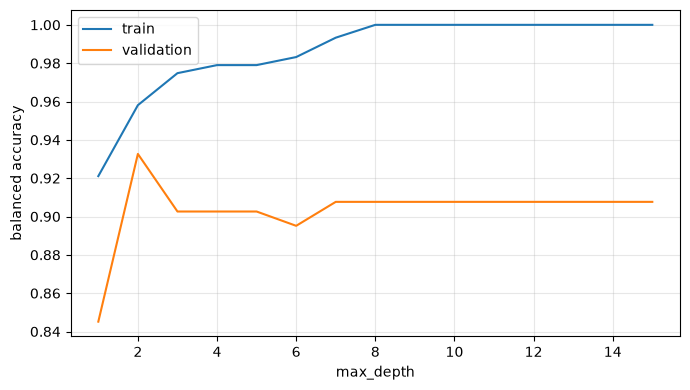

In [11]:
# --- Overfitting check: score vs max_depth ---
# Split the training set once more into train/validation so we can compare
# how the model does on data it has seen (train) vs data it has not (validation).
Xtr2, Xva, ytr2, yva = train_test_split(Xb_tr, yb_tr, test_size=0.25,
                                        stratify=yb_tr, random_state=SEED)
depths = range(1, 16)
train_s, val_s = [], []
for d in depths:
    clf = DecisionTree(criterion='gini', problem_type='classification',
                       max_depth=d, random_state=SEED).fit(Xtr2, ytr2)
    train_s.append(balanced_accuracy_score(ytr2, clf.predict(Xtr2)))
    val_s.append(balanced_accuracy_score(yva, clf.predict(Xva)))

# If the validation curve rises then plateaus/falls while train keeps rising,
# that is overfitting: the tree memorizes training data but stops generalizing.
plt.figure(figsize=(7, 4))
plt.plot(list(depths), train_s, label='train')
plt.plot(list(depths), val_s, label='validation')
plt.xlabel('max_depth'); plt.ylabel('balanced accuracy'); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

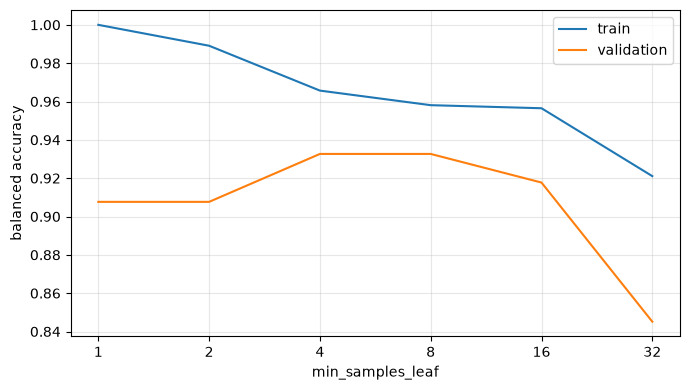

In [12]:
# --- Overfitting check: score vs min_samples_leaf ---
# Larger leaves -> smoother, more regularized tree -> validation should be more stable.
leafs = [1, 2, 4, 8, 16, 32]
train_s, val_s = [], []
for ml in leafs:
    clf = DecisionTree(criterion='gini', problem_type='classification',
                       min_samples_leaf=ml, random_state=SEED).fit(Xtr2, ytr2)
    train_s.append(balanced_accuracy_score(ytr2, clf.predict(Xtr2)))
    val_s.append(balanced_accuracy_score(yva, clf.predict(Xva)))
plt.figure(figsize=(7, 4))
plt.plot([str(x) for x in leafs], train_s, label='train')
plt.plot([str(x) for x in leafs], val_s, label='validation')
plt.xlabel('min_samples_leaf'); plt.ylabel('balanced accuracy'); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">در نمودار عمق، بیش‌برازش را کجا می‌بینی؟ کدام پارامترها نقش «منظم‌ساز» دارند و به نظرت مقدار معقول برای <code dir="ltr">max_depth</code> و <code dir="ltr">min_samples_leaf</code> چیست؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> در عمق‌های بزرگ نمره‌ی آموزش به‌سوی ۱ می‌رود، ولی نمره‌ی اعتبارسنجی اول بالا می‌رود و بعد تقریباً ثابت می‌ماند یا کمی نوسان می‌کند؛ همان فاصله‌ای که بین دو منحنی باز می‌شود، نشانه‌ی بیش‌برازش است. منظم‌سازها عبارت‌اند از: <code dir="ltr">max_depth</code> (محدودکردن عمق)، <code dir="ltr">min_samples_split</code> و <code dir="ltr">min_samples_leaf</code> (توقف زودهنگام) و هرس <code dir="ltr">ccp_alpha</code>. برای این داده مقادیر معقول حدود عمق ۳ تا ۷ و <code dir="ltr">min_samples_leaf</code> حدود ۴ تا ۱۶ است.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۷ — جینی در برابر آنتروپی (تجربی)</h2><p style="text-align: right;">تا اینجا گفتیم جینی و آنتروپی «تقریباً یک‌چیزند». حالا خودت قضاوت کن: دو درخت بساز که همه پارامترهایشان یکی باشد و فقط معیارشان فرق کند (<code dir="ltr">gini</code> در برابر <code dir="ltr">entropy</code>)، بعد نمره‌شان را مقایسه کن.</p></div>

In [13]:
# --- Empirical check: does criterion choice matter? ---
# Two trees identical except for gini vs entropy. Expect very similar scores.
t_g = DecisionTree(criterion='gini', problem_type='classification',
                   max_depth=5, random_state=SEED).fit(Xb_tr, yb_tr)
t_e = DecisionTree(criterion='entropy', problem_type='classification',
                   max_depth=5, random_state=SEED).fit(Xb_tr, yb_tr)
print("gini    balanced acc:", round(balanced_accuracy_score(yb_te, t_g.predict(Xb_te)), 4))
print("entropy balanced acc:", round(balanced_accuracy_score(yb_te, t_e.predict(Xb_te)), 4))

gini    balanced acc: 0.9345
entropy balanced acc: 0.9495


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">جینی و آنتروپی نتیجه متفاوتی دادند؟ این مشاهده چطور تأیید می‌کند که «تقریباً معادل‌اند»؟ اگر فرق جزئی دیدی، چه چیزی می‌تواند باعثش باشد؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> روی داده‌ی کامل (۳۰ ویژگی) جینی ۰٫۹۳۴۵ و آنتروپی ۰٫۹۴۹۵ شد؛ کمی متفاوت ولی هر دو در همان محدوده‌ی خوب. این تفاوت جزئی دقیقاً از اینجا می‌آید که دو معیار در چند گره تقسیم‌های کمی متفاوت انتخاب می‌کنند، اما چون ناخالصی‌ها بسیار شبیه‌اند، نمره‌ی نهایی نزدیک می‌ماند. پس «تقریباً یک‌چیزند» یعنی در عمل فرق مهمی در نتیجه ایجاد نمی‌کنند.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ۸ — مرز تصمیم (Decision Boundary)</h2><p style="text-align: right;">تا حالا فقط عدد و نمودار عمق دیدیم. حالا بگذار خودِ درخت را <b>ببینیم</b>! مرز تصمیم، خطِ جدایی است که مدل بین کلاس‌ها می‌کشد. مشکل این است که سرطان پستان ۳۰ ویژگی دارد و نمی‌توانیم فضای ۳۰ بعدی را رسم کنیم.</p><p style="text-align: right;">راه‌حل رایج: فقط <b>دو ویژگی</b> را انتخاب می‌کنیم (مثلاً <code dir="ltr">mean radius</code> و <code dir="ltr">mean texture</code>)، درخت را روی همین دو ستون می‌سازیم و برای هر نقطه از یک شبکه‌ی ریز (meshgrid) روی این دو محور، پیش‌بینی درخت را می‌گیریم. به این ترتیب ناحیه‌های «مستطیلی» که درخت تصمیم می‌سازد را می‌بینیم.</p><p style="text-align: right;">اول تابع کمکی <code dir="ltr">plot_decision_boundary</code> را بنویس که شبکه را می‌سازد، برای همه نقاطش پیش‌بینی می‌گیرد و با <code dir="ltr">contourf</code> رنگ‌آمیزی می‌کند و نقاط واقعی را هم رویش می‌اندازد:</p></div>

In [14]:
# Helper: plot the decision regions of a fitted tree on 2 features.
def plot_decision_boundary(tree, X2, y, ax, pad=0.5):
    # X2 is the TRAINING data restricted to the 2 chosen columns.
    # 1) a fine grid over both feature ranges
    xs = np.linspace(X2[:, 0].min() - pad, X2[:, 0].max() + pad, 300)
    ys = np.linspace(X2[:, 1].min() - pad, X2[:, 1].max() + pad, 300)
    xx, yy = np.meshgrid(xs, ys)

    # 2) predict the class for EVERY grid point and reshape back to the grid
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # 3) draw the regions and overlay the real points
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdBu_r')
    for c in np.unique(y):
        ax.scatter(X2[y == c, 0], X2[y == c, 1], s=14, edgecolor='k',
                   label=f'class {c}')
    ax.set_xlabel('feature 0'); ax.set_ylabel('feature 1'); ax.legend()

2-feature gini    balanced acc: 0.8973
2-feature entropy balanced acc: 0.8646


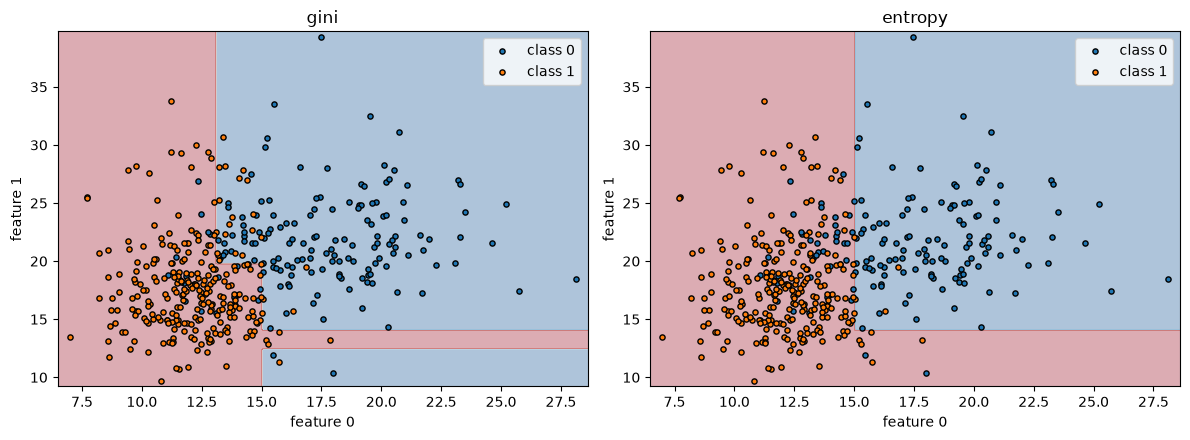

In [15]:
# --- Train two 2-feature trees (gini vs entropy) and compare their boundaries ---
feat = [0, 1]  # 'mean radius' and 'mean texture'
Xb2_tr = Xb_tr[:, feat]
Xb2_te = Xb_te[:, feat]

t_g2 = DecisionTree(criterion='gini', problem_type='classification',
                    max_depth=3, random_state=SEED).fit(Xb2_tr, yb_tr)
t_e2 = DecisionTree(criterion='entropy', problem_type='classification',
                    max_depth=3, random_state=SEED).fit(Xb2_tr, yb_tr)

print("2-feature gini    balanced acc:",
      round(balanced_accuracy_score(yb_te, t_g2.predict(Xb2_te)), 4))
print("2-feature entropy balanced acc:",
      round(balanced_accuracy_score(yb_te, t_e2.predict(Xb2_te)), 4))

# Side-by-side boundaries: visually they should be almost identical.
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
plot_decision_boundary(t_g2, Xb2_tr, yb_tr, axs[0]); axs[0].set_title('gini')
plot_decision_boundary(t_e2, Xb2_tr, yb_tr, axs[1]); axs[1].set_title('entropy')
plt.tight_layout(); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right;">بحث کنید</h3><p style="text-align: right;">دو مرز تصمیم (جینی و آنتروپی) را با هم مقایسه کن؛ چقدر به هم شبیه‌اند؟ این هم یک دلیل بصری است که چرا می‌گوییم این دو معیار «تقریباً یک‌چیزند». آیا جایی هست که ناحیه‌ها دقیقاً یکسان نباشند؟</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><p style="text-align: right;"><b>پاسخ پیشنهادی:</b> دو مرز تقریباً روی هم می‌افتند و ناحیه‌های اصلی یکی هستند. فقط در چند لبه یا گوشه ممکن است یک تقسیم کوچک متفاوت شود (چون معیارها کاملاً یکسان نیستند)، ولی ساختار کلی و نمره‌ی نهایی نزدیک می‌ماند. این هم یک تأیید بصری از همان ادعاست: جینی و آنتروپی تقریباً به یک درخت می‌رسند.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">فاز ارزیابی — نتیجه کار خودتان را ببینید</h2><p style="text-align: right;">حالا وقت جمع‌بندی است. سلول زیر با پیاده‌سازی <b>تو</b>، درخت طبقه‌بندی را روی سرطان پستان و درخت رگرسیون را روی مسکن کالیفرنیا برازش کرده و معیارها را چاپ می‌کند. اجرا کن و ببین چقدر به مقدار مرجع نزدیک هستی.</p></div>

In [16]:
# Evaluation cell - run it and compare with the reference value.
# It uses YOUR implementation (DecisionTree), so it only works once the
# implementation cells above are filled in.
clf_eval = DecisionTree(criterion='gini', problem_type='classification',
                        max_depth=5, random_state=SEED).fit(Xb_tr, yb_tr)
ba = balanced_accuracy_score(yb_te, clf_eval.predict(Xb_te))
print(f"from-scratch classifier balanced accuracy: {ba:.4f}")

reg_eval = DecisionTree(criterion='mse', problem_type='regression',
                        max_depth=5, random_state=SEED).fit(Xc_tr, yc_tr)
r2 = r2_score(yc_te, reg_eval.predict(Xc_te))
print(f"from-scratch regressor R2: {r2:.4f}")

from-scratch classifier balanced accuracy: 0.9345


from-scratch regressor R2: 0.6019


In [17]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer reference values (SEED=42, max_depth=5):
#   from-scratch classifier balanced accuracy: ~0.9345
#   from-scratch regressor R2:                 ~0.6019
# Student outputs should be close to these (small numeric differences are fine).

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h2 style="text-align: right;">اختیاری — هرس با هزینه-پیچیدگی (ccp_alpha)</h2><p style="text-align: right;">حالا که فرمول <code dir="ltr">ccp_alpha</code> را خواندی، وقت عمل است. با <code dir="ltr">DecisionTreeClassifier</code> مسیر هرس را با <code dir="ltr">cost_complexity_pruning_path</code> ببین، یک مقدار <code dir="ltr">alpha</code> انتخاب کن که بیش‌برازش را کم کند و نتیجه را با حالت بدون هرس مقایسه کن. اگر دوست داشتی، با <code dir="ltr">plot_tree</code> ساختار درخت را هم رسم کن تا ببینی هرس چطور آن را کوچک می‌کند.</p></div>

In [18]:
# TODO (optional): cost-complexity pruning with sklearn.
# cost_complexity_pruning_path returns the alphas at which the tree changes;
# each alpha is a penalty per leaf. Pick one and see how pruning helps.
path = DecisionTreeClassifier(criterion='gini', random_state=SEED).cost_complexity_pruning_path(Xb_tr, yb_tr)
ccp = path.ccp_alphas
# Fit trees for a few alphas and compare train vs validation balanced accuracy.